## Project: CNN-based segmentation of cells in multi-modal microscopy images

Contact: Karl Rohr (Heidelberg University K.Rohr@dkfz-heidelberg.de)

### Introduction

Cell segmentation is a central task in biomedical image analysis and enables counting the cell number, quantifying single-cell fluorescence intensity, and tracking of cells to analyze cell motion. Challenges are high variation of cell shape and image intensity, strong image noise, low image contrast, and high cell density. Deep learning methods for cell segmentation in microscopy data show promising results.

### Goal

The goal of this project is to develop a Convolutional Neural Network (CNN) to automatically segment cells in microscopy images. A modified 2D U-Net model (Ronneberger et al., MICCAI 2015, Falk et al., Nature Methods 2019) will be implemented and applied to image data from different imaging modalities comprising fluorescence, differential interference contrast (DIC), and phase-contrast microscopy. Different versions of the network model will be generated by training on data from individual imaging modalities as well as a combination of different imaging modalities. The trained models are applied to the different datasets, and the segmentation accuracy will be quantified by a performance metric. The experimental results are analyzed and a comparison of the different network models will be carried out.

### Data and model

The [2D U-Net model](https://link.springer.com/chapter/10.1007/978-3-319-24574-4_28) will be used as a basis. Zero-padding (SAME padding) in the convolution layers should be included to ensure that the output size of the network is the same as the input size. This eliminates the need for cropping and resizing of the images in the original model. Experiments with different network configurations should be performed (e.g., different number of layers). Besides using a Cross-Entropy Loss as in the original model, a Dice Loss or a combination of both losses should be investigated. Also, loss weighting as in the original model should be tested. Existing implementations of the U-Net can be used as inspiration.

The network model should be applied to [datasets from the Cell Tracking Challenge](https://celltrackingchallenge.net/2d-datasets/) (Ulman et al., Nature Methods 2017) comprising 2D time-lapse microscopy image data of three different imaging modalities:
1. Fluorescence microscopy: HeLa cells stably expressing H2b-GFP ([download](http://data.celltrackingchallenge.net/training-datasets/Fluo-N2DL-HeLa.zip))
2. Differential interference contrast (DIC) microscopy: HeLa cells on a flat glass ([download](http://data.celltrackingchallenge.net/training-datasets/DIC-C2DH-HeLa.zip))
3. Phase-contrast microscopy: Glioblastoma-astrocytoma U373 cells on a polyacrylamide substrate ([download](http://data.celltrackingchallenge.net/training-datasets/PhC-C2DH-U373.zip))

Each dataset consists of two image sequences from which single images should be used as samples. The images can be found in the folders `01` and `02`. Since the "gold truth" provided in the folders `01_GT/SEG` and `02_GT/SEG` is not available for all single images or cells, the "silver truth" in `01_ST/SEG` or `02_ST/SEG`can be used. More information on the datasets can be found [here](https://celltrackingchallenge.net/). One of the two image sequences should be used for training and the other for testing. The labels are instance labels (with a different ID for each cell), which need to be converted to semantic labels (foreground-background).

Different versions of the network model should be generated by training on data from individual imaging modalities as well as a combination of different imaging modalities. A comparison of the different network models should be performed. The Jaccard Index (Intersection over Union) can be used as segmentation performance metric. A strategy needs to be found to deal with large image sizes (e.g., using image resizing or image tiling as in the original model). To improve the segmentation result, different preprocessing and data augmentation strategies can be studied. Information on deep learning for image segmentation and the U-Net is provided in the lecture (Karl Rohr).


### References
Ronneberger 0, Fischer P, Brox T. (2015) [U-Net: Convolutional Networks for Biomedical Image Segmentation](https://link.springer.com/chapter/10.1007/978-3-319-24574-4_28), MICCAI 2015, 234–241

Falk T, Brox T, Ronneberger O et al. (2019) [U-Net: deep learning for cell counting, detection, and morphometry](https://www.nature.com/articles/s41592-018-0261-2), Nature Methods 16, 67-70

Ulman V, Maška M, Harder N, Rohr K, Kozubek M, Ortiz-de-Solorzano C, et al. (2017) [An objective comparison of cell-tracking algorithms](https://www.nature.com/articles/nmeth.4473), Nature Methods 14, 1141–1152




In [1]:
# Install pytorch.lightning and ClearML
%pip install lightning
%pip install clearml
%pip install memory-profiler
%load_ext memory_profiler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Imports and data loading

In [2]:
# import of necessary libraries
import os
import torch
import scipy
import random
import numpy as np
import seaborn as sns
import torch.nn as nn
from torch.nn import init
import lightning.pytorch as pl
import matplotlib.pyplot as plt
import torch.nn.functional as F

from PIL import Image
from clearml import Task
from copy import deepcopy
from tqdm.notebook import tqdm
from skimage.transform import resize
from typing import Tuple, List, Dict
from torchvision.transforms import Compose
from torchmetrics.segmentation import MeanIoU
from torch.utils.data import DataLoader, Dataset
from lightning.pytorch.callbacks import ModelCheckpoint

In [3]:
# Settings for ClearML

%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
%env CLEARML_API_ACCESS_KEY=7LV78E9ZO25RYVT5N2KBNGLDBN8RHG
%env CLEARML_API_SECRET_KEY=x7iabI85eU32Khl9qxvVm6QBd6ZgjwoVNhmvIj49q-YFFJoUIwYU20bScY4IbDa8d-0

env: CLEARML_WEB_HOST=https://app.clear.ml/
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml
env: CLEARML_API_ACCESS_KEY=7LV78E9ZO25RYVT5N2KBNGLDBN8RHG
env: CLEARML_API_SECRET_KEY=x7iabI85eU32Khl9qxvVm6QBd6ZgjwoVNhmvIj49q-YFFJoUIwYU20bScY4IbDa8d-0


In [4]:
# Get Data
!unzip /content/data/DIC-C2DH-HeLa.zip -d /content/data
# !unzip /content/data//PhC-C2DH-U373.zip -d /content/data
# !unzip /content/data/Fluo-N2DL-HeLa.zip -d /content/data

DATASET_PATH = "/content/data"
CHECKPOINT_PATH = "/content/models"

DIC_PATH = "/DIC-C2DH-HeLa"
PHC_PATH = "/PhC-C2DH-U373"
FLUO_PATH = "/Fluo-N2DL-HeLa"

TRAIN_IMAGE = "/01"
TRAIN_LABELS = "/01_ST"
TRAIN_GOLDEN = "/01_GT"
VAL_IMAGE = "/02"
VAL_LABELS = "/02_ST"

DIC_TRAIN_DATA = DATASET_PATH + DIC_PATH + TRAIN_IMAGE
DIC_TRAIN_GOLDEN = DATASET_PATH + DIC_PATH + TRAIN_GOLDEN
DIC_TRAIN_LABELS = DATASET_PATH + DIC_PATH + TRAIN_LABELS
DIC_VAL_DATA = DATASET_PATH + DIC_PATH + VAL_IMAGE
DIC_VAL_LABELS = DATASET_PATH + DIC_PATH + VAL_LABELS

Archive:  /content/data/DIC-C2DH-HeLa.zip
   creating: /content/data/DIC-C2DH-HeLa/
   creating: /content/data/DIC-C2DH-HeLa/01/
  inflating: /content/data/DIC-C2DH-HeLa/01/t000.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t001.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t002.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t003.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t004.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t005.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t006.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t007.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t008.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t009.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t010.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t011.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t012.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t013.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t014.tif  
  inflating: /content/data/DIC-C2DH-HeLa/01/t0

In [5]:
# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [6]:
def set_seed(seed: int = 42) -> None:
    """ Function setting the seed.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    pl.seed_everything(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


In [7]:
def list_files_in_folder(folder_path: str) -> List[str]:
    """ Function returns a list of paths to
    all files in the given folder.

    Args:
      folder_path (str): Path to the folder.

    Returns:
      file_paths (List[str]): List of file paths.
    """
    file_paths = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_paths.append(os.path.join(root, file))
    return file_paths

In [8]:
def get_image_label_paths(data_folder: str,
                          silver_label_folder: str,
                          golden_label_folder: str = None,
                          golden: bool = False) -> Tuple[List[str], List[str], List[bool]]:
    """ Function to get lists of image and label paths, including both silver and
    golden truth when golden=True. Also returns a list indicating if each sample
    is golden truth. If an image has both silver and golden truth labels,
    both pairs are included.

    Args:
        data_folder (str): Path to the image data folder.
        silver_label_folder (str): Path to the silver-truth label data folder
        golden_label_folder (str, optional): Path to the golden-truth label data folder
        golden (bool): If True, include golden-truth labels as well as silver-truth. Defaults to False.

    Returns:
        Tuple[List[str], List[str], List[bool]]: Lists of image paths, corresponding label paths,
                                                 and a list of booleans (True if golden truth, False if silver).
                                                 The order of the returned lists corresponds to the order of samples.
    """
    image_paths = []
    label_paths = []
    is_golden_truth_list = []
    golden_truth_map = {}
    silver_truth_map = {}

    # Golden Truth
    if golden and golden_label_folder:
        golden_seg_folder = os.path.join(golden_label_folder, 'SEG')
        if os.path.exists(golden_seg_folder):
             for root, _, files in os.walk(golden_seg_folder):
                for file in files:
                    if file.startswith('man_seg') and file.endswith('.tif'):
                        try:
                            num_str = file.replace('man_seg', '').replace('.tif', '')
                            frame_number = int(num_str)
                            image_filename = f't{frame_number:03}.tif'
                        except ValueError:
                             print(f"Warning: Could not parse golden label filename '{file}'.")
                             continue

                        found_image_path = None
                        # Search for the corresponding image in data_folder
                        for root_data, _, files_data in os.walk(data_folder):
                            if image_filename in files_data:
                                found_image_path = os.path.join(root_data, image_filename)
                                break

                        if found_image_path:
                            golden_truth_map[found_image_path] = os.path.join(root, file)
                        else:
                            print(f"Warning: Corresponding image '{image_filename}' for golden label '{file}' not found in '{data_folder}'.")
        else:
            print(f"WARNING: Golden truth folder not found at '{silver_seg_folder}'.")


    # Silver Truth
    silver_seg_folder = os.path.join(silver_label_folder, 'SEG')
    if os.path.exists(silver_seg_folder):
        for root, _, files in os.walk(silver_seg_folder):
            for file in files:
                 if file.startswith('man_seg') and file.endswith('.tif'):
                     try:
                         num_str = file.replace('man_seg', '').replace('.tif', '')
                         frame_number = int(num_str)
                         image_filename = f't{frame_number:03}.tif'
                     except ValueError:
                         print(f"WARNING: Could not parse from silver label filename '{file}'.")
                         continue

                     found_image_path = None
                     for root_data, _, files_data in os.walk(data_folder):
                         if image_filename in files_data:
                             found_image_path = os.path.join(root_data, image_filename)
                             break

                     if found_image_path:
                         silver_truth_map[found_image_path] = os.path.join(root, file)
                     else:
                         print(f"WARNING: Corresponding image '{image_filename}' for silver label '{file}' not found in '{data_folder}'.")
    else:
        print(f"WARNING: Silver truth folder not found at '{silver_seg_folder}'.")

    all_image_paths_with_labels = sorted(list(set(golden_truth_map.keys()).union(set(silver_truth_map.keys()))))

    for image_path in all_image_paths_with_labels:
        # Add silver truth
        if image_path in silver_truth_map:
            image_paths.append(image_path)
            label_paths.append(silver_truth_map[image_path])
            is_golden_truth_list.append(False)

        # Mark as golden truth
        if golden and image_path in golden_truth_map:
            image_paths.append(image_path)
            label_paths.append(golden_truth_map[image_path])
            is_golden_truth_list.append(True)


    return image_paths, label_paths, is_golden_truth_list

# Utilities and data augmentation

In [9]:
def plot_images(*args):
    """ Function to plot multiple images for
    different augmentations.
    """
    f,ax = plt.subplots(1,len(args), figsize=(24, 24))
    for i in range(len(args)):
        ax[i].imshow(args[i][0], cmap="inferno")
        ax[i].set_title(args[i][1])
        ax[i].axis("off")
    plt.show()
    plt.close()


def plot_heatmap(data: np.ndarray) -> None:
    """ Function to plot a heatmap of the given data
    or labels.

    Args:
        data (np.ndarray): The data to plot.
    """
    plt.figure(figsize=(12, 6))
    plt.imshow(data, cmap='inferno', interpolation='nearest')
    plt.colorbar()
    plt.show()
    plt.close()


def channel_comparison(tensor: torch.Tensor):
    """ Function that returns the output of the model as 1 if there is
    foreground at the given position, and zero if background.

    Args:
        tensor (torch.Tensor): The output of the model.

    Returns:
        np.ndarray: The comparison result of foreground and background.
    """
    if tensor.shape != (1, 2, 512, 512):
        raise ValueError("Input tensor must have shape (1, 2, 512, 512)")

    # Extract the first and second channels
    first_channel = tensor[0, 0, :, :]
    second_channel = tensor[0, 1, :, :]

    # Compare the values
    comparison_result = (second_channel > first_channel).numpy().astype(np.uint8)

    return comparison_result


def plot_results(arr1, arr2, arr3):

    # Setting up the figure and axes
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    min_val = min(arr1.min(), arr2.min(), arr3.min())
    max_val = max(arr1.max(), arr2.max(), arr3.max())

    # Creating heatmaps
    sns.heatmap(arr1, ax=axs[0], cbar=False, cmap='viridis')
    axs[0].set_title('Orginal image')
    axs[0].set_xticks([])
    axs[0].set_yticks([])

    sns.heatmap(arr2, ax=axs[1], cbar=False, cmap='viridis', vmin=min_val, vmax=max_val)
    axs[1].set_title('Label')
    axs[1].set_xticks([])
    axs[1].set_yticks([])

    sns.heatmap(arr3, ax=axs[2], cbar=False,cmap='viridis', vmin=min_val, vmax=max_val)
    axs[2].set_title('Model prediction')
    axs[2].set_xticks([])
    axs[2].set_yticks([])

    plt.tight_layout()
    plt.show()

In [10]:
class TIF_dataset_GT(Dataset):

    def __init__(self,
                 image_paths: List[str],
                 label_paths: List[str],
                 is_golden_truth: List[bool],
                 image_transform_standard = None,
                 label_transform_standard = None,
                 image_transform_golden = None,
                 label_transform_golden = None,
                 dataset_maximum = None) -> None:
        """ Class for storing data with the same .tif extension, both silver and
        gold true with different augmentation to optimise training.
        Images are labelled with the specified tags.

        Args:
            image_paths (List[str]): List of image paths.
            label_paths (List[str]): List of label paths.
            is_golden_truth (List[bool]): List of booleans indicating if each
                                          sample is golden truth.
            image_transform_standard (Compose): Image transform for silver data.
            label_transform_standard (Compose): Label transform for silver data.
            image_transform_golden (Compose): Image transform for golden data.
            label_transform_golden (Compose): Label transform for golden data.
            dataset_maximum (int): Maximum value in goal for  normalization.

        Returns:
            None
        """

        self.image_paths = image_paths
        self.label_paths = label_paths
        self.is_golden_truth = is_golden_truth
        self.image_transform_standard = image_transform_standard
        self.label_transform_standard = label_transform_standard
        self.image_transform_golden = image_transform_golden
        self.label_transform_golden = label_transform_golden
        self.dataset_maximum = dataset_maximum

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx: int) -> torch.Tensor:
        image_path = self.image_paths[idx]
        label_path = self.label_paths[idx]
        is_golden_truth = self.is_golden_truth[idx]

        image = Image.open(image_path)
        np_image = np.array(image).astype('float32')

        label = Image.open(label_path)
        np_label = np.array(label).astype('float32')
        np_label = np.where(np_label != 0, 1, 0).astype('float32')


        if is_golden_truth:
            if self.image_transform_golden:
                np_image = self.image_transform_golden(np_image)
            if self.label_transform_golden:
                np_label = self.label_transform_golden(np_label)
        else:
            if self.image_transform_standard:
                np_image = self.image_transform_standard(np_image)
            if self.label_transform_standard:
                np_label = self.label_transform_standard(np_label)

        image_tensor = torch.from_numpy(np_image.copy()).unsqueeze(0).float()
        label_tensor = torch.from_numpy(np_label.copy()).unsqueeze(0).float()

        # Normalizing the images
        if self.dataset_maximum is None:
            image_tensor = (image_tensor - torch.mean(image_tensor)) / torch.std(image_tensor)
        else:
            image_tensor = image_tensor / self.dataset_maximum

        return image_tensor, label_tensor

In [12]:
class TIF_dataset_ST(Dataset):

    def __init__(self,
                 path_list_data,
                 path_list_label,
                 image_transform = None,
                 label_transform = None,
                 dataset_maximum = None):
        """ Class for storing data with the same .tif extension for
        only data silver truth. Images are labelled with the specified tags.

        Args:
            path_list_data (List[str]): List of image paths.
            path_list_label (List[str]): List of label paths.
            image_transform (Compose): Image transform for silver data.
            label_transform (Compose): Label transform for silver data.
            dataset_maximum (int): Maximum value in goal for  normalization.

        Returns:
            None
        """


        self.path_list_data = path_list_data
        self.path_list_label = path_list_label
        self.image_transform = image_transform
        self.label_transform = label_transform
        self.dataset_maximum = dataset_maximum

    def __len__(self):
        return len(self.path_list_data)

    def __getitem__(self, idx):
        image = Image.open(self.path_list_data[idx])
        image_np = np.array(image).astype('float32')
        label = Image.open(self.path_list_label[idx])
        label_np = np.array(label).astype('float32')
        label_np = np.where(label_np != 0, 1, label_np)

        if self.image_transform:
            image_np = self.image_transform(image_np)
            label_np = self.label_transform(label_np)

        image_tensor = torch.from_numpy(image_np.copy()).unsqueeze(0).float()
        label_tensor = torch.from_numpy(label_np.copy()).unsqueeze(0).float()

        if self.dataset_maximum == None:
            image_tensor = (image_tensor - np.mean(image_np))/np.std(image_np) #normalizing the image tensor
        else:
            image_tensor = image_tensor / self.dataset_maximum #normalizing the image tensor

        return image_tensor, label_tensor

In [13]:
X_train_silver = list_files_in_folder(DIC_TRAIN_DATA)
Y_train_silver = list_files_in_folder(DIC_TRAIN_LABELS)
X_val = list_files_in_folder(DIC_VAL_DATA)
Y_val = list_files_in_folder(DIC_VAL_LABELS)

print("Number of training images found:", len(X_train_silver))
print("Number of testing labels found:", len(Y_train_silver))
print("Number of testing images found:", len(X_val))
print("Number of testing labels found:", len(Y_val))

Number of training images found: 84
Number of testing labels found: 84
Number of testing images found: 84
Number of testing labels found: 84


In [14]:
X_train, Y_train, is_golden_train = get_image_label_paths(DIC_TRAIN_DATA,
                                                          DIC_TRAIN_LABELS,
                                                          golden_label_folder=DIC_TRAIN_GOLDEN,
                                                          golden=True
                                    )

print("Number of training images found:", len(X_train))
print("Number of training labels found:", len(Y_train))
print("Number of golden truth flags:", len(is_golden_train))
print("Sample Image Paths:", X_train[:4])
print("Sample Label Paths:", Y_train[:4])
print("Sample Golden Truth Flags:", is_golden_train[:4])

Number of training images found: 93
Number of training labels found: 93
Number of golden truth flags: 93
Sample Image Paths: ['/content/data/DIC-C2DH-HeLa/01/t000.tif', '/content/data/DIC-C2DH-HeLa/01/t001.tif', '/content/data/DIC-C2DH-HeLa/01/t002.tif', '/content/data/DIC-C2DH-HeLa/01/t002.tif']
Sample Label Paths: ['/content/data/DIC-C2DH-HeLa/01_ST/SEG/man_seg000.tif', '/content/data/DIC-C2DH-HeLa/01_ST/SEG/man_seg001.tif', '/content/data/DIC-C2DH-HeLa/01_ST/SEG/man_seg002.tif', '/content/data/DIC-C2DH-HeLa/01_GT/SEG/man_seg002.tif']
Sample Golden Truth Flags: [False, False, False, True]


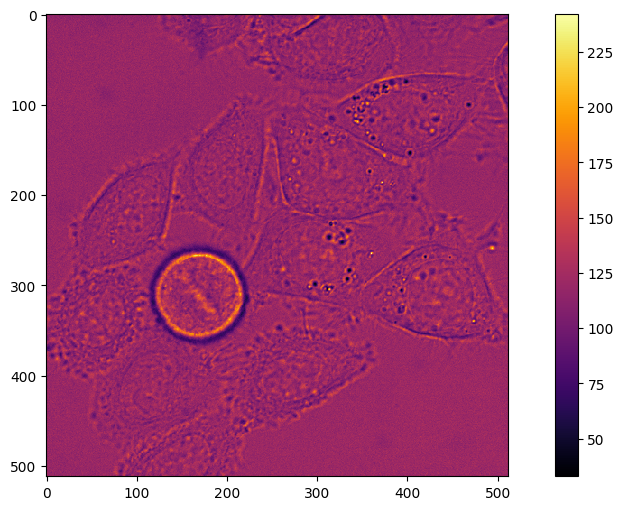

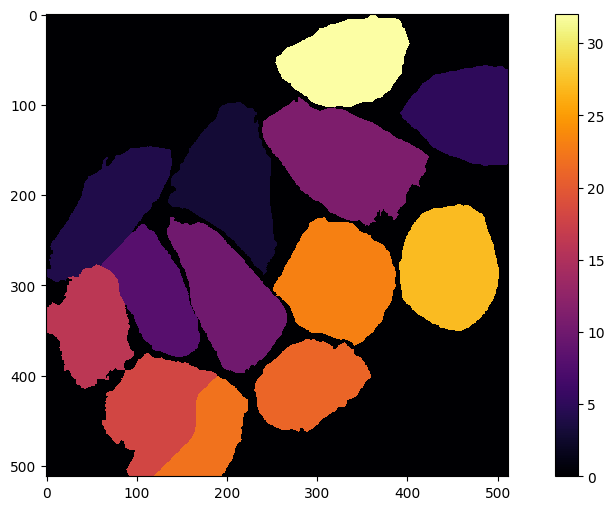

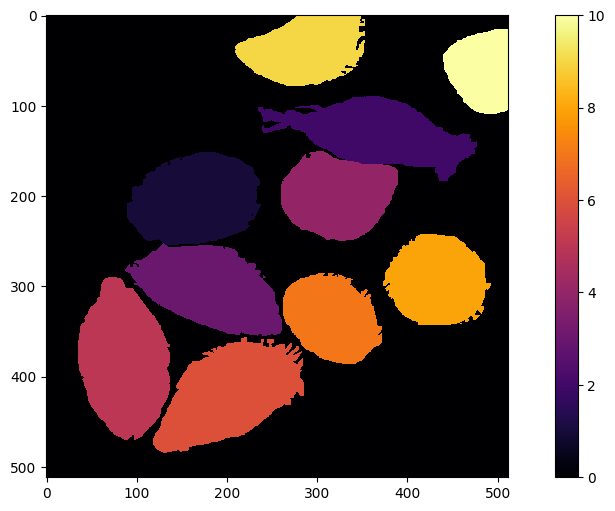

In [15]:
# Schow example image
EXAMPLE_INDEX = 2
image = Image.open(X_train_silver[EXAMPLE_INDEX])
silver_label = Image.open(Y_train_silver[EXAMPLE_INDEX])
golden_label = Image.open(Y_train[EXAMPLE_INDEX + 1])

plot_heatmap(image)
plot_heatmap(silver_label)
plot_heatmap(golden_label)

# Utilities and data augmentation

In [45]:
# Classes for data augmentations

class RandomRotate90():
    def __init__(self, random_state, execution_probability=0.0):
        self.random_state = random_state
        self.execution_probability = execution_probability

    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            k = self.random_state.randint(1,4)
            return np.rot90(x,k)
        return x

class RandomContrast():
    def __init__(self, random_state, scale, execution_probability=0.0):
        self.random_state = random_state
        self.execution_probability = execution_probability
        self.scale = scale
    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            lam = self.random_state.uniform(np.max((0, 1 - self.scale)), 1 + self.scale)
            return np.clip(x * lam, 0, 255)
        return x

class RandomBrightness():
    def __init__(self,random_state, scale, execution_probability=0.0):
        self.random_state = random_state
        self.execution_probability = execution_probability
        self.scale = scale
    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            lam = 255 * self.scale * self.random_state.uniform(-1,1)
            return np.clip(x + lam, 0, 255)
        return x

class RandomElasticDeformation():
    def __init__(self, random_state, grid_size, sigma, order, execution_probability=0.0):
        self.random_state = random_state
        self.grid_size = grid_size
        self.sigma = sigma
        self.order = order
        self.execution_probability = execution_probability

    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            h,w = x.shape

            dx = self.random_state.randn(*[self.grid_size, self.grid_size]) * self.sigma
            dy = self.random_state.randn(*[self.grid_size, self.grid_size]) * self.sigma

            dx = resize(dx, x.shape, preserve_range=True, order = 3)
            dy = resize(dy, x.shape, preserve_range=True, order = 3)

            idx_x, idx_y = np.meshgrid(np.arange(h), np.arange(w))

            coordinates = idx_y + dy, idx_x + dx

            return scipy.ndimage.map_coordinates(x, coordinates, order = self.order, mode = "reflect", prefilter=False)
        return x



class RandomRotate():
    def __init__(self,
                 random_state: int,
                 angle_range: float,
                 execution_probability: float = 0.0,
                 mode: str = "mirror",
                 order: int = 0,
                 reshape: bool = False):
        self.random_state = random_state
        self.angle_range = angle_range # List specifing the angle range, i.e. [angle_min, angle_max]
        self.execution_probability = execution_probability
        self.mode = mode
        self.order = order
        self.reshape = reshape

    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            angle = self.random_state.uniform(self.angle_range[0], self.angle_range[1])
            return scipy.ndimage.rotate(x, angle, reshape=self.reshape, mode=self.mode, order=self.order)
        return x


class AugmentationPipeline():
    def __init__(self,
                 random_state=None,
                 rotate_p=0.5,
                 elastic_p=0.5,
                 contrast_p=0.5,
                 brightness_p=0.5,
                 contrast_scale=0.1,
                 brightness_scale=0.1):
        self.rs = np.random.RandomState() if random_state is None else random_state
        self.image_transforms = [
            RandomRotate90(self.rs, rotate_p),
            RandomElasticDeformation(self.rs, grid_size=4, sigma=8, order=1, execution_probability=elastic_p),
            RandomContrast(self.rs, contrast_scale, execution_probability=contrast_p),
            RandomBrightness(self.rs, brightness_scale, execution_probability=brightness_p)
        ]
        self.label_transforms = [
            RandomRotate90(self.rs, rotate_p),
            RandomElasticDeformation(self.rs, grid_size=4, sigma=8, order=0, execution_probability=elastic_p)
        ]

    def __call__(self, image, label):
        for t in self.label_transforms:
            label = t(label)
        for t in self.image_transforms:
            image = t(image)
        return image, label


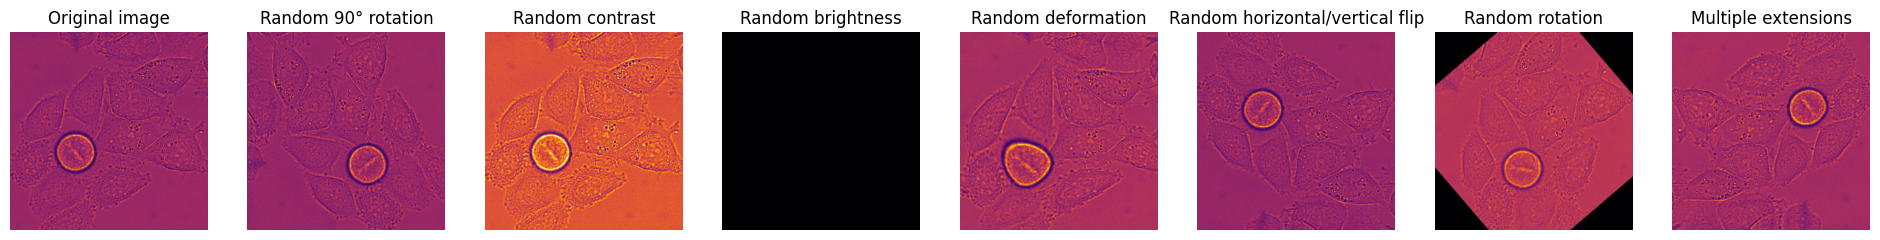

In [17]:
image =  np.array(Image.open(X_train_silver[EXAMPLE_INDEX])).astype('float32')
silver_label = np.array(Image.open(Y_train_silver[EXAMPLE_INDEX])).astype('float32')
golden_label = np.array(Image.open(Y_train[EXAMPLE_INDEX + 1])).astype('float32')

rot90 = RandomRotate90(random_state=np.random.RandomState(SEED),
                       execution_probability=1)(image)
contrast = RandomContrast(random_state=np.random.RandomState(SEED),
                          scale=0.5,
                          execution_probability=1)(image)
brightness = RandomBrightness(random_state=np.random.RandomState(SEED),
                              scale=1,
                              execution_probability=1)(image)
deform = RandomElasticDeformation(random_state=np.random.RandomState(SEED),
                                  grid_size=3,
                                  sigma=25,
                                  order=3,
                                  execution_probability=1)(image)
flip = RandomFlip(random_state=np.random.RandomState(SEED),
                  execution_probability=1)(image)
rot = RandomRotate(random_state=np.random.RandomState(SEED),
                   angle_range=[-45,45],
                   execution_probability=1,
                   mode = "constant")(image)
custom, _ = AugmentationPipeline(random_state=np.random.RandomState(SEED),
                              rotate_p=1,
                              elastic_p=1,
                              contrast_p=1,
                              brightness_p=1)(image, silver_label)

plot_images(
    [image, "Original image"],
    [rot90, "Random 90° rotation"],
    [contrast, "Random contrast"],
    [brightness, "Random brightness"],
    [deform, "Random deformation"],
    [flip, "Random horizontal/vertical flip"],
    [rot, "Random rotation"],
    [custom, "Multiple extensions"]
)

In [19]:
# Example of data augmentation
execution_probability = 0.1

image_transforms_train = Compose([
    RandomRotate90(random_state=np.random.RandomState(SEED), execution_probability=execution_probability),
    RandomElasticDeformation(random_state=np.random.RandomState(SEED), grid_size=3, sigma=10, order=3, execution_probability=execution_probability),
    RandomContrast(random_state=np.random.RandomState(SEED), scale=0.1, execution_probability=execution_probability),
    RandomBrightness(random_state=np.random.RandomState(SEED), scale=0.1, execution_probability=execution_probability)
])

label_transforms_train = Compose([
    RandomRotate90(random_state=np.random.RandomState(SEED), execution_probability=execution_probability),
    RandomElasticDeformation(random_state=np.random.RandomState(SEED), grid_size=3, sigma=10, order=1, execution_probability=execution_probability),
])


golden_image_transforms_train = Compose([
    RandomRotate90(random_state=np.random.RandomState(SEED), execution_probability=execution_probability),
    RandomElasticDeformation(random_state=np.random.RandomState(SEED), grid_size=3, sigma=10, order=3, execution_probability=execution_probability),
    RandomContrast(random_state=np.random.RandomState(SEED), scale=0.1, execution_probability=execution_probability),
    RandomBrightness(random_state=np.random.RandomState(SEED), scale=0)
])

golden_label_transforms_train = Compose([
    RandomRotate90(random_state=np.random.RandomState(SEED), execution_probability=execution_probability),
    RandomElasticDeformation(random_state=np.random.RandomState(SEED), grid_size=2, sigma=20, order=1, execution_probability=execution_probability),
])

# Losses and Metrics

In [31]:
# Losses during training
def miou(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    intersection = torch.mean((y_true==1).float() * (y_pred==1).float())
    union = torch.mean((y_true==1).float() + (y_pred==1).float()) - intersection
    miou = intersection / union
    return miou

def Dice(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    numerator = 2 * np.sum(y_pred * y_true, axis = (1,2))
    denominator = np.sum(y_pred, axis = (1,2)) + np.sum(y_pred, axis = (1,2))
    return np.mean(numerator / denominator)

def IoU(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    numerator = np.sum(y_pred * gt, axis = (1,2))
    denominator = np.sum(y_pred, axis = (1,2)) + np.sum(y_true, axis = (1,2))
    denominator -= np.sum(y_pred * y_true, axis = (1,2))
    return np.mean(numerator / denominator)

def MIoU(y_true, y_pred) -> float:
    intersection = torch.mean((y_true==1).float() * (y_pred==1).float())
    union = torch.mean((y_true==1).float() + (y_pred==1).float()) - intersection
    miou = intersection / union
    return miou

In [21]:
# Classes for loss computation

class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()

    def forward(self,
                y_pred: torch.Tensor,
                y_true: torch.Tensor,
                eps: float = 1e-8) -> float:
        loss = 1.0

        for c in range(2):
            y_pred_c = y_pred[:, c, :, :]
            y_true_c = (y_true == c).float()
            intersection = torch.sum(y_pred_c * y_true_c)
            union = torch.sum(y_pred_c) + torch.sum(y_true_c)
            dice_coeff = (2 * intersection + eps) / (union + eps)
            loss -= (dice_coeff / 2)

        return loss


class ComboLoss(nn.Module):
    def __init__(self,
                 alpha: float) -> float:
        super(ComboLoss, self).__init__()
        self.dice_loss = DiceLoss()
        self.bce_loss = nn.CrossEntropyLoss()
        self.alpha = alpha

    def forward(self,
                y_pred: torch.Tensor,
                y_true: torch.Tensor) -> float:
        loss = self.alpha * self.dice_loss(y_pred, y_true)
        loss += (1.0 - self.alpha) * self.bce_loss(y_pred, y_true)
        return loss


class LogCoshDiceLoss(nn.Module):
    def __init__(self):
        super(LogCoshDiceLoss, self).__init__()
        self.dice_loss = DiceLoss()

    def forward(self,
                y_pred: torch.Tensor,
                y_true: torch.Tensor) -> float:
        return torch.log(torch.cosh(self.dice_loss(y_pred, y_true)))

In [23]:
train_dataset = TIF_dataset_ST(X_train_silver, Y_train_silver, image_transforms_train, label_transforms_train)
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_dataset = TIF_dataset_ST(X_val, Y_val)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

## UNet

In [24]:
# Initialize weights

def init_weights(m, init_type='normal', gain=0.02):
    classname = m.__class__.__name__
    if hasattr(m, 'weight') and (classname.find('Conv') != -1 or classname.find('Linear') != -1):
        if init_type == 'normal':
            init.normal_(m.weight.data, 0.0, gain)
        elif init_type == 'xavier':
            init.xavier_normal_(m.weight.data, gain=gain)
        elif init_type == 'kaiming':
            init.kaiming_normal_(m.weight.data, a=0, mode='fan_in')
        elif init_type == 'orthogonal':
            init.orthogonal_(m.weight.data, gain=gain)
        else:
            raise NotImplementedError(f"Initialization method [{init_type}] is not implemented")
        if hasattr(m, 'bias') and m.bias is not None:
            init.constant_(m.bias.data, 0.0)
    elif classname.find('BatchNorm2d') != -1:
        init.normal_(m.weight.data, 1.0, gain)
        init.constant_(m.bias.data, 0.0)

In [25]:
class Convolutional_Block(nn.Module):

    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size=3,
                 padding=1,
                 stride=1,
                 dropout = 0.1):
        super(Convolutional_Block, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn1 = nn.BatchNorm2d(num_features=out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn2 = nn.BatchNorm2d(num_features=out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn3 = nn.BatchNorm2d(num_features=out_channels)
        self.dropout = nn.Dropout(p=dropout, inplace=False)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.dropout(self.relu(self.bn1(self.conv1(x))))
        residual = x
        x = self.dropout(self.relu(self.bn2(self.conv2(x))))
        x = self.dropout(self.relu(self.bn3(self.conv3(x))))
        x = x + residual
        return x

In [46]:
class UNet(pl.LightningModule):

    def __init__(self,
                 list_of_chanel_numbers,
                 crop = None,
                 loss_fn = torch.nn.CrossEntropyLoss(),
                 lr = 0.001,
                 betas = (0.9, 0.999),
                 kernel_size=3,
                 dropout = 0.1,
                 padding = 1,
                 log = False,
                 len_train = 1,
                 len_val = 1):
        super(UNet, self).__init__()
        self.list_of_chanel_numbers = deepcopy(list_of_chanel_numbers)
        self.channel_pairs = [(list_of_chanel_numbers[i], list_of_chanel_numbers[i+1]) for i in range(len(list_of_chanel_numbers) - 1)]
        self.bottom_path = nn.ModuleList()
        self.top_path = nn.ModuleList()
        self.UpConvs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size = 2)
        for pair in self.channel_pairs:
            c_in, c_out = pair
            self.bottom_path.append(Convolutional_Block(c_in, c_out, kernel_size=kernel_size, dropout = dropout, padding = padding))
        self.bottom_block = Convolutional_Block(list_of_chanel_numbers[-1], list_of_chanel_numbers[-1], kernel_size=kernel_size, dropout = dropout, padding=padding)
        self.channel_pairs[0] = (2, list_of_chanel_numbers[1]) # 2 classes
        self.channel_pairs.reverse()
        for pair in self.channel_pairs:
            c_out, c_in = pair
            self.UpConvs.append(torch.nn.ConvTranspose2d(c_in, c_in, kernel_size = 2, stride = 2, ))
            self.top_path.append(Convolutional_Block(c_in, c_out, kernel_size=kernel_size, dropout = dropout, padding=padding))

        self.crop = crop
        self.loss_fn = loss_fn
        self.lr = lr
        self.betas = betas
        self.allow_logging = log
        self.kernel_size = kernel_size
        self.padding = padding
        self.dropout = dropout

        self.avg_train_loss = 0
        self.avg_val_loss = 0
        self.val_miou = 0
        self.len_train = len_train
        self.len_val = len_val

    def forward(self, x):
        residuals = []
        for i, module in enumerate(self.bottom_path):
            x = module(x)
            residuals.append(x)
            if i < len((self.bottom_path)):
                x = self.pool(x)

        residuals.reverse()
        x = self.bottom_block(x)

        for i, module in enumerate(self.top_path):
            if i >= 0:
                x = self.UpConvs[i](x)
            x = x + residuals[i]
            x = module(x)

        x = F.softmax(x, dim=1)

        return x

    def training_step(self, batch, batch_idx):
        inputs, labels = batch

        if self.crop != None:
            inputs = inputs[:, :, :self.crop, :self.crop]
            labels = labels[:, :, :self.crop, :self.crop]

        labels = labels.squeeze().long()
        outputs = self.forward(inputs)
        loss = self.loss_fn(outputs, labels)

        self.avg_train_loss += loss

        # print(f'TRRAINING: Batch {batch_idx}, loss {loss}')
        self.log('Training Loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        self.eval()
        with torch.no_grad():
            inputs, labels = batch

            if self.crop != None:
                inputs = inputs[:, :, :self.crop, :self.crop]
                labels = labels[:, :, :self.crop, :self.crop]

            labels = labels.squeeze().long()
            outputs = self.forward(inputs)
            loss = self.loss_fn(outputs, labels)

            self.avg_val_loss += loss
            self.val_miou += miou(outputs.argmax(1), labels)

            # print(f'   VALIDATION: Batch {batch_idx}, loss {loss}')
            self.log('Validation Loss', loss, on_step=True, on_epoch=True, prog_bar=True)
            self.log('Validation MIoU', self.val_miou, on_step=True, on_epoch=True, prog_bar=True)
            return loss

    def on_validation_epoch_end(self):
        self.log('Mean Validation MIoU', self.val_miou/self.len_val, on_step=False, on_epoch=True, prog_bar=True)
        if self.allow_logging:
            print(f'Epoch {self.current_epoch}, Training loss: {self.avg_train_loss/self.len_train}, Validation loss: {self.avg_val_loss/self.len_val}, Validation MIoU: {self.val_miou/self.len_val}')
        self.avg_train_loss = 0
        self.avg_val_loss = 0
        self.val_miou = 0

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr = self.lr, betas = self.betas)

    def generate_numpy_output_from_single_image(self, img):
        model_return_numpy = channel_comparison(self(img).detach().cpu())
        return model_return_numpy

## UNet++ https://arxiv.org/pdf/1807.10165

In [38]:
class UNetPlus(UNet):

    def __init__(self,
                 list_of_chanel_numbers,
                 crop = None,
                 loss_fn = torch.nn.CrossEntropyLoss(),
                 lr = 0.001,
                 betas = (0.9, 0.999),
                 kernel_size=3,
                 dropout = 0.1,
                 padding = 1,
                 log = False,
                 len_train = 1,
                 len_val = 1,
                 init_type: str = "normal",
                 gain: float = 0.02,
                 task_name: str = None):
        super(UNetPlus, self).__init__(list_of_chanel_numbers, crop, loss_fn, lr, betas, kernel_size, dropout, padding, log, len_train, len_val)

        self.horizontal_blocks = nn.ModuleList()
        self.list_of_chanel_numbers[0] = 2
        for i in range(len(self.bottom_path)):
            self.horizontal_blocks.append(nn.ModuleList([
                Convolutional_Block(self.list_of_chanel_numbers[j], self.list_of_chanel_numbers[j], dropout=dropout, padding=padding)
                for j in range(len(self.list_of_chanel_numbers)-i-1)]))
        self.horizontal_blocks[0][0] = Convolutional_Block(1, self.list_of_chanel_numbers[0], dropout=dropout, padding=padding)

        self.match_chanels = nn.ModuleList([
            nn.Conv2d(list_of_chanel_numbers[i+1], list_of_chanel_numbers[i], kernel_size=1)
            for i in range(len(list_of_chanel_numbers)-1)
        ])

        # ClearML init
        self.task = None
        if task_name:
            params = {"lr": lr,
                      "betas": betas,
                      "loss_fn": loss_fn.__class__.__name__,
                      "init_type": init_type,
                      "gain": gain,
            }
            self.task = Task.init(project_name="CNN-based segmentation",
                                  task_name=task_name)
            self.task.connect(params)

        # Initialize weights
        # self.apply(lambda m: init_weights(m, init_type, gain))

    def forward(self, x):
        residuals = [x]
        for i, module in enumerate(self.bottom_path):
            x = module(x)
            residuals.append(x)
            if i < len((self.bottom_path)):
                x = self.pool(x)
        residuals_skip = [res.clone() for res in residuals]
        res = []

        for i in range(len(self.horizontal_blocks)):
            for j in range(len(self.horizontal_blocks[i])):
                prev = F.interpolate(residuals[j+1],residuals[j].shape[-2:],mode="bilinear")
                prev = self.match_chanels[j](prev)
                residuals[j] = self.horizontal_blocks[i][j](residuals[j]+prev)
                if j == 0:
                    res.append(residuals[j])
        residuals.reverse()
        residuals_skip.reverse()
        x = self.bottom_block(x)

        for i, module in enumerate(self.top_path):
            if i >= 0:
                x = self.UpConvs[i](x)
            x = x + residuals[i] + residuals_skip[i]
            x = module(x)

        res.append(x)
        res = [F.softmax(r, dim = 1) for r in res]

        return res

    def training_step(self, batch, batch_idx):
        inputs, labels = batch

        if self.crop != None:
            inputs = inputs[:, :, :self.crop, :self.crop]
            labels = labels[:, :, :self.crop, :self.crop]

        labels = labels.squeeze().long()
        outputs = self.forward(inputs)
        loss = 0
        for o in outputs:
            loss += self.loss_fn(o, labels)
        loss /= len(outputs)

        self.avg_train_loss += loss

        self.log('Training Loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        self.eval()
        with torch.no_grad():
            inputs, labels = batch

            if self.crop != None:
                inputs = inputs[:, :, :self.crop, :self.crop]
                labels = labels[:, :, :self.crop, :self.crop]

            labels = labels.squeeze().long()
            outputs = self.forward(inputs)
            loss = 0
            for o in outputs:
                loss += self.loss_fn(o, labels)
            loss /= len(outputs)

            self.avg_val_loss += loss
            self.val_miou += miou(outputs[-1].argmax(1), labels)

            self.log('Validation Loss', loss, on_step=True, on_epoch=True, prog_bar=True)
            self.log('Validation MIoU', self.val_miou, on_step=True, on_epoch=True, prog_bar=True)
            return loss

    def generate_numpy_output_from_single_image(self, img):
        model_return_numpy = channel_comparison(self(img)[-1].detach().cpu())
        return model_return_numpy

## Attention UNet https://arxiv.org/pdf/1804.03999

In [39]:
class AttentionBlock(nn.Module):
    def __init__(self, current_channel, lower_channel):
        super(AttentionBlock, self).__init__()
        self.current_channel = current_channel
        self.lower_channel = lower_channel
        self.conv1 = nn.Conv2d(current_channel, lower_channel, kernel_size=1, stride=1 if current_channel == 1 else 2) # last 2 levels have the same size
        self.conv2 = nn.Conv2d(lower_channel, lower_channel, kernel_size=1)
        self.conv3 = nn.Conv2d(lower_channel, lower_channel, kernel_size=1)
        self.bn = nn.BatchNorm2d(lower_channel)
        self.dropout = nn.Dropout(p=0.5, inplace=False)

    def forward(self, x, residual):
        x0 = x.clone()
        x = self.conv1(residual) + self.conv2(x)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.bn(x)
        x = self.conv3(x)
        x = torch.sigmoid(x)
        x = F.interpolate(x, x0.shape[-2:], mode="bilinear")
        return x0 * x

In [40]:
class AttentionUNet(UNet):
    def __init__(self,
                 list_of_chanel_numbers,
                 crop=None,
                 loss_fn=torch.nn.CrossEntropyLoss(),
                 lr=0.001,
                 betas=(0.9, 0.999),
                 kernel_size=3,
                 dropout=0.1,
                 padding=1,
                 log=False,
                 len_train=1,
                 len_val=1,
                 init_type: str = "normal",
                 gain: float = 0.02,
                 task_name: str = None):
        super().__init__(list_of_chanel_numbers, crop, loss_fn, lr, betas, kernel_size, dropout, padding, log, len_train, len_val)
        self.attention_blocks = nn.ModuleList([
            AttentionBlock(current_channel, lower_channel)
            for current_channel, lower_channel in zip(self.list_of_chanel_numbers[::-1][1:], self.list_of_chanel_numbers[::-1][:-1])
        ])

        # ClearML init
        self.task = None
        if task_name:
            params = {"lr": lr,
                      "betas": betas,
                      "loss_fn": loss_fn.__class__.__name__,
                      "init_type": init_type,
                      "gain": gain,
            }
            self.task = Task.init(project_name="CNN-based segmentation",
                                  task_name=task_name)
            self.task.connect(params)

        # Initialize weights
        # self.apply(lambda m: init_weights(m, init_type, gain))


    def forward(self, x):
        residuals = [x]
        for i, module in enumerate(self.bottom_path):
            x = module(x)
            residuals.append(x)
            if i < len((self.bottom_path)):
                x = self.pool(x)

        residuals.pop(-1)
        residuals.reverse()
        x = self.bottom_block(x)

        for i, module in enumerate(self.top_path):
            x = self.UpConvs[i](x)
            x = x + self.attention_blocks[i](x, residuals[i])
            x = module(x)

        x = F.softmax(x, dim=1)

        return x

# BiFPN

In [47]:
class Recurrent_block(nn.Module):
    def __init__(self, ch_out, t=2):
        super().__init__()
        self.t = t
        self.ch_out = ch_out
        self.conv = nn.Sequential(
            nn.Conv2d(ch_out, ch_out, kernel_size=3, stride=1, padding=1, bias=True),
            nn.BatchNorm2d(ch_out),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        for i in range(self.t):
            if i == 0:
                x1 = self.conv(x)
            x1 = self.conv(x + x1)
        return x1

In [48]:
class RRCNN_block(nn.Module):
    def __init__(self, ch_in, ch_out, t=2):
        super().__init__()
        self.Conv_1x1 = nn.Conv2d(ch_in, ch_out, kernel_size=1, stride=1, padding=0)
        self.RCNN = nn.Sequential(
            Recurrent_block(ch_out, t=t),
            Recurrent_block(ch_out, t=t)
        )

    def forward(self, x):
        x = self.Conv_1x1(x)
        x1 = self.RCNN(x)
        return x + x1

In [49]:
class BiFPN(nn.Module):
    def __init__(self, channels, epsilon=1e-4):
        super().__init__()
        self.epsilon = epsilon
        self.conv6_up = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv5_up = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv4_up = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv4_down = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv5_down = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv6_down = nn.Conv2d(channels, channels, 3, padding=1)
        self.w1 = nn.Parameter(torch.Tensor(2,3))  # for top-down and bottom-up
        nn.init.constant_(self.w1, 1)
        self.relu = nn.ReLU()

    def forward(self, p4, p5, p6):
        # top-down
        w = self.relu(self.w1[0]); w = w / (torch.sum(w, dim=0) + self.epsilon)
        p6_up = p6
        p5_td = self.conv5_up(w[0]*p5 + w[1]*F.interpolate(p6_up, scale_factor=2, mode='nearest'))
        p4_td = self.conv4_up(w[0]*p4 + w[1]*F.interpolate(p5_td, scale_factor=2, mode='nearest'))
        # bottom-up
        w2 = self.relu(self.w1[1]); w2 = w2 / (torch.sum(w2, dim=0) + self.epsilon)
        p4_out = p4_td
        p5_out = self.conv5_down(w2[0]*p5_td + w2[1]*F.max_pool2d(p4_out,2))
        p6_out = self.conv6_down(w2[0]*p6 + w2[1]*F.max_pool2d(p5_out,2))
        return p4_out, p5_out, p6_out

In [53]:
class UNet_BiFPN_RRCNN(pl.LightningModule):
    def __init__(self, channels, loss_fn, lr=1e-3, betas=(0.9,0.999),
                 init_type='kaiming', gain=0.02, log_experiment=False,
                 len_train=1, len_val=1, weight_alpha=10, weight_sigma=5):
        super().__init__()
        if log_experiment:
            self.task = Task.init(project_name="UNet_BiFPN_RRCNN", task_name="BiFPN")
        self.enable_logging = log_experiment
        self.loss_fn = loss_fn
        self.lr, self.betas = lr, betas
        self.len_train, self.len_val = len_train, len_val
        self.train_loss_accum = self.val_loss_accum = self.val_miou_accum = 0.0
        self.weight_alpha, self.weight_sigma = weight_alpha, weight_sigma
        # Encoder with RRCNN
        self.enc1 = RRCNN_block(channels[0], channels[1])
        self.pool = nn.MaxPool2d(2)
        self.enc2 = RRCNN_block(channels[1], channels[2])
        self.enc3 = RRCNN_block(channels[2], channels[3])
        # BiFPN on features at levels
        self.bifpn = BiFPN(channels[3])
        # Bottleneck
        self.bottleneck = RRCNN_block(channels[3], channels[4])
        # Decoder
        self.up3 = nn.ConvTranspose2d(channels[4], channels[3], 2, stride=2)
        self.dec3 = Convolutional_Block(channels[4], channels[3])
        self.up2 = nn.ConvTranspose2d(channels[3], channels[2], 2, stride=2)
        self.dec2 = Convolutional_Block(channels[3], channels[2])
        self.up1 = nn.ConvTranspose2d(channels[2], channels[1], 2, stride=2)
        self.dec1 = Convolutional_Block(channels[2], channels[1])
        self.out_conv = nn.Conv2d(channels[1], channels[0], 1)
        # Init weights
        self.apply(lambda m: init_weights(m, init_type, gain))

    def create_weight_map(self, mask):
        # from UNet: border-weight map via max and min pooling
        mask = mask.squeeze(1)
        mask_float = mask.float()
        # max pool
        pooled_max = F.max_pool2d(mask_float, kernel_size=3, padding=1)
        # min pool via negation
        pooled_min = -F.max_pool2d(-mask_float, kernel_size=3, padding=1)
        borders = pooled_max - pooled_min
        weight = 1 + self.weight_alpha * torch.exp(- (borders ** 2) / (2 * self.weight_sigma ** 2))
        return weight

    def forward(self, x):
        # encode
        e1 = self.enc1(x); p1 = self.pool(e1)
        e2 = self.enc2(p1); p2 = self.pool(e2)
        e3 = self.enc3(p2)
        # BiFPN feature fusion
        f3, f2, f1 = self.bifpn(e1, e2, e3)
        # bottleneck
        b = self.bottleneck(f1)
        # decode
        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, f3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, f2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, f1], dim=1))
        out = self.out_conv(d1)
        return F.softmax(out, dim=1)

    def training_step(self, batch, idx):
        img, mask = batch
        weight_map = self.create_weight_map(mask)
        logits = self(img)
        loss = self.loss_fn(logits, mask.squeeze().long(), weight_map)
        self.train_loss_accum += loss.item()
        self.log('train_loss', loss, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, idx):
        img, mask = batch
        weight_map = self.create_weight_map(mask)
        logits = self(img)
        loss = self.loss_fn(logits, mask.squeeze().long(), weight_map)
        miou_val = miou(logits.argmax(1), mask.squeeze().long())
        self.val_loss_accum += loss.item()
        self.val_miou_accum += miou_val
        self.log('val_loss', loss, on_epoch=True)
        self.log('val_miou', miou_val, on_epoch=True)
        return loss

    def on_validation_epoch_end(self):
        epoch = int(self.current_epoch)
        avg_loss = self.val_loss_accum / self.len_val
        avg_miou = self.val_miou_accum / self.len_val
        if self.enable_logging:
            logger = self.task.get_logger()
            logger.report_scalar("Validation", "Loss", epoch, avg_loss)
            logger.report_scalar("Validation", "MIoU", epoch, avg_miou)
        self.train_loss_accum = self.val_loss_accum = self.val_miou_accum = 0.0

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr, betas=self.betas)

## Training

In [54]:
def train_model(model, train_dataloader, val_dataloader):
    set_seed(SEED)
    trainer.fit(model, train_dataloader, val_dataloader)
    model.load_state_dict(torch.load(checkpoint.best_model_path, weights_only=True)['state_dict'])
    try:
        model.task.close()
    except:
        print("The model did not use ClearML")

    return model

def plot_example_output(model, val_dataset):
    data, label = val_dataset[EXAMPLE_INDEX]
    model.eval()
    model.to(device)
    model_output = model.generate_numpy_output_from_single_image(data.unsqueeze(1).to(device))

    print('Model output')
    plot_heatmap(model_output)

    print('Label')
    plot_heatmap(label.squeeze().numpy())

    print('original image')
    plot_heatmap(data.squeeze().numpy())

In [42]:
SIZES = [1, 4, 16, 64]

In [43]:
model = AttentionUNet(SIZES,
                      log=True,
                      len_train=len(train_dataloader),
                      len_val=len(val_dataloader),
                      loss_fn=LogCoshDiceLoss(),
                      task_name='Attention U-Net'
                      ).to(device)

checkpoint = ModelCheckpoint(dirpath=CHECKPOINT_PATH,
                             save_top_k=3,
                             monitor="Mean Validation MIoU",
                             mode="max"

)
trainer = pl.Trainer(max_epochs=64,
                     log_every_n_steps=1,
                     callbacks=[checkpoint]
)

ClearML Task: created new task id=77ff7351124c45d1b99ab75db29f9f2d
ClearML results page: https://app.clear.ml/projects/5bef593faa9547b598bd6a01eea31fc8/experiments/77ff7351124c45d1b99ab75db29f9f2d/output/log


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: UserWarning:

Checkpoint directory /content/models exists and is not empty.

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name             | Type                | Params | Mode 
-----------------------------------------------------------------
0 | bottom_path      | ModuleList          | 89.2 K | train
1 | top_path         | ModuleList          | 15.0 K | train
2 | UpConvs          | ModuleList          | 17.6 K | train
3 | pool             | MaxPool2d           | 0      | train
4 | bottom_block     | Convolutional_Block | 111 K  | train
5 | loss_fn          | LogCoshDiceLoss     | 0      | train
6 | attention_blocks | ModuleList          | 10.2 K | train
-----------------------------------------------------------------
243 K  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Epoch 0, Training loss: 0.0, Validation loss: 0.08018796145915985, Validation MIoU: 0.0020056385546922684


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 62, Training loss: 0.024322064593434334, Validation loss: 0.16238783299922943, Validation MIoU: 0.09477152675390244


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=64` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=64` reached.


Epoch 63, Training loss: 0.023582573980093002, Validation loss: 0.04320826753973961, Validation MIoU: 0.5372712016105652
Model output


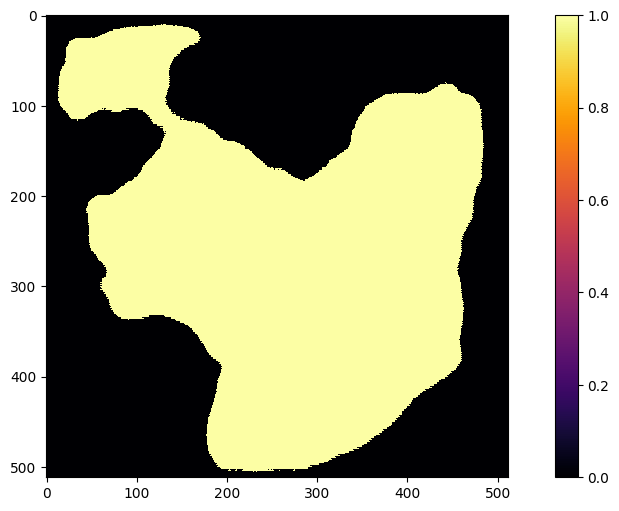

Label


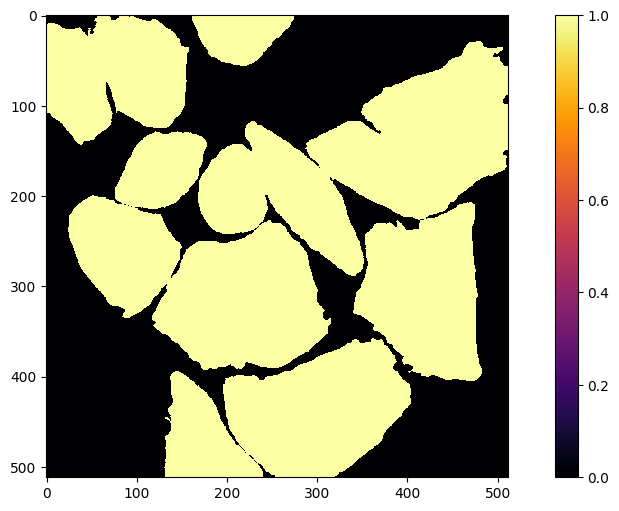

original image


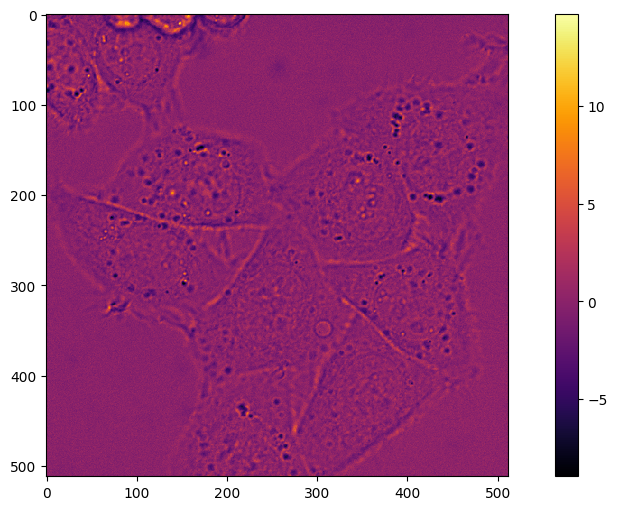

In [44]:
model = train_model(model, train_dataloader, val_dataloader)
plot_example_output(model, val_dataset)

In [55]:
SIZES = [1, 4, 8, 16, 32, 64]

model = UNet_BiFPN_RRCNN(SIZES,
                      log_experiment=False,
                      len_train=len(train_dataloader),
                      len_val=len(val_dataloader),
                      loss_fn=LogCoshDiceLoss(),
                      ).to(device)


model = train_model(model, train_dataloader, val_dataloader)
plot_example_output(model, val_dataset)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
   | Name       | Type                | Params | Mode 
------------------------------------------------------------
0  | loss_fn    | LogCoshDiceLoss     | 0      | train
1  | enc1       | RRCNN_block         | 320    | train
2  | pool       | MaxPool2d           | 0      | train
3  | enc2       | RRCNN_block         | 1.2 K  | train
4  | enc3       | RRCNN_block         | 4.8 K  | train
5  | bifpn      | BiFPN               | 13.9 K | train
6  | bottleneck | RRCNN_block         | 19.2 K | train
7  | up3        | ConvTranspose2d     | 2.1 K  | train
8  | dec3       | Convolutional_Block | 9.4 K  | train
9  | up2        | ConvTranspose2d     | 520    | train
10 | dec2       | Convolutional_Block | 2.4 K  | train
11 | up1        | ConvTranspose2d     | 132    | train
12 | dec1    

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

RuntimeError: The size of tensor a (8) must match the size of tensor b (16) at non-singleton dimension 1